In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib as mpl
from scipy.stats import binned_statistic
import matplotlib.gridspec as gridspec

plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
# =================================================================
# 1. SETUP & LOADING
# =================================================================
BASE_DIR = '/home/storgaard/OneDrive/Speciale/Halofit/C_256+2048' 


def load_sim_folder(folder_path):
    """Loads all z-files in a folder into a dictionary: data[z_val] = (k, Ck)"""
    files = glob.glob(os.path.join(folder_path, "Ck_z*.txt"))
    data_dict = {}
    for f in files:
        match = re.search(r'Ck_z([\d\.]+)\.txt', os.path.basename(f))
        if match:
            z_val = round(float(match.group(1)), 2)
            data = np.loadtxt(f, skiprows=1)
            data_dict[z_val] = (data[:, 0], data[:, 1])
    return data_dict

print("Loading baseline...")
base_data = load_sim_folder(os.path.join(BASE_DIR, "baseline")) 

var_data = {'dNeff': {}, 'fidm': {}}
for folder_name in os.listdir(BASE_DIR):
    if folder_name == "baseline": continue
        
    match = re.match(r'(dNeff|fidm)_([+-]?[\d\.]+)', folder_name)
    if not match: continue
        
    param_name = match.group(1)
    delta_val = float(match.group(2))
    
    print(f"Loading {param_name} = {delta_val}...")
    var_data[param_name][delta_val] = load_sim_folder(os.path.join(BASE_DIR, folder_name))

Loading baseline...
Loading dNeff = 0.5...
Loading dNeff = 1.0...
Loading dNeff = 1.5...
Loading dNeff = 2.0...
Loading dNeff = -0.5...
Loading dNeff = -1.0...
Loading dNeff = -1.5...
Loading dNeff = -2.0...
Loading fidm = 0.5...
Loading fidm = 1.0...
Loading fidm = 1.5...
Loading fidm = 2.0...
Loading fidm = -0.5...
Loading fidm = -1.0...
Loading fidm = -1.5...
Loading fidm = -2.0...


In [3]:
# =================================================================
# 2. LOG-BINNING AND CALCULATING RESPONSE FUNCTIONS
# =================================================================
delta_x = 256 / 512 
k_nyquist = np.pi / delta_x
k_cut = 0.75 * k_nyquist
n_log_bins = 25

print(f"Nyquist frequency: {k_nyquist:.3f} 1/Mpc. Hard cutting data at: {k_cut:.3f} 1/Mpc.")

response_functions = {'dNeff': {}, 'fidm': {}} 

# --- NEW: Dictionaries to store the binned data so we NEVER bin twice ---
binned_base = {} 
binned_var = {'dNeff': {}, 'fidm': {}}

for param in ['dNeff', 'fidm']:
    delta_vals = np.array(list(var_data[param].keys()))
    if len(delta_vals) == 0: continue
        
    for z in base_data.keys():
        k_raw, Ck_base_raw = base_data[z]
        
        valid_mask = k_raw <= k_cut
        k_valid = k_raw[valid_mask]
        Ck_base_valid = Ck_base_raw[valid_mask]
        
        bins = np.logspace(np.log10(k_valid.min()), np.log10(k_valid.max()), n_log_bins + 1)
        
        k_binned, _, _  = binned_statistic(k_valid, k_valid, statistic='mean', bins=bins)
        Ck_base_binned, _, _ = binned_statistic(k_valid, Ck_base_valid, statistic='mean', bins=bins)
        
        nan_mask = ~np.isnan(k_binned) & ~np.isnan(Ck_base_binned)
        k_binned = k_binned[nan_mask]
        Ck_base_binned = Ck_base_binned[nan_mask]
        
        # Save baseline to dictionary
        if z not in binned_base:
            binned_base[z] = (k_binned, Ck_base_binned)
        
        y_matrix = []
        valid_x = []
        
        for d_val in delta_vals:
            if z in var_data[param][d_val]:
                _, Ck_var_raw = var_data[param][d_val][z]
                Ck_var_valid = Ck_var_raw[valid_mask]
                
                Ck_var_binned, _, _ = binned_statistic(k_valid, Ck_var_valid, statistic='mean', bins=bins)
                Ck_var_binned = Ck_var_binned[nan_mask]
                
                # Save varied model to dictionary
                if d_val not in binned_var[param]:
                    binned_var[param][d_val] = {}
                binned_var[param][d_val][z] = (k_binned, Ck_var_binned)
                
                y_matrix.append(Ck_var_binned - Ck_base_binned)
                valid_x.append(d_val)
                
        y_matrix = np.array(y_matrix)
        valid_x = np.array(valid_x)
        
        if len(valid_x) > 0:
            numerator = np.dot(valid_x, y_matrix) 
            denominator = np.sum(valid_x**2)
            slope_array = numerator / denominator
            
            sigma_array = np.ones_like(k_binned)
            if param == 'fidm' and z > 0.3:
                emphasis_mask = k_binned > 1.5
                sigma_array[emphasis_mask] = 0.1
            
            response_functions[param][z] = (k_binned, slope_array, sigma_array)

print(f"\nResponse functions, weights, and binned arrays cached using {n_log_bins} log-bins!")

Nyquist frequency: 6.283 1/Mpc. Hard cutting data at: 4.712 1/Mpc.

Response functions, weights, and binned arrays cached using 25 log-bins!


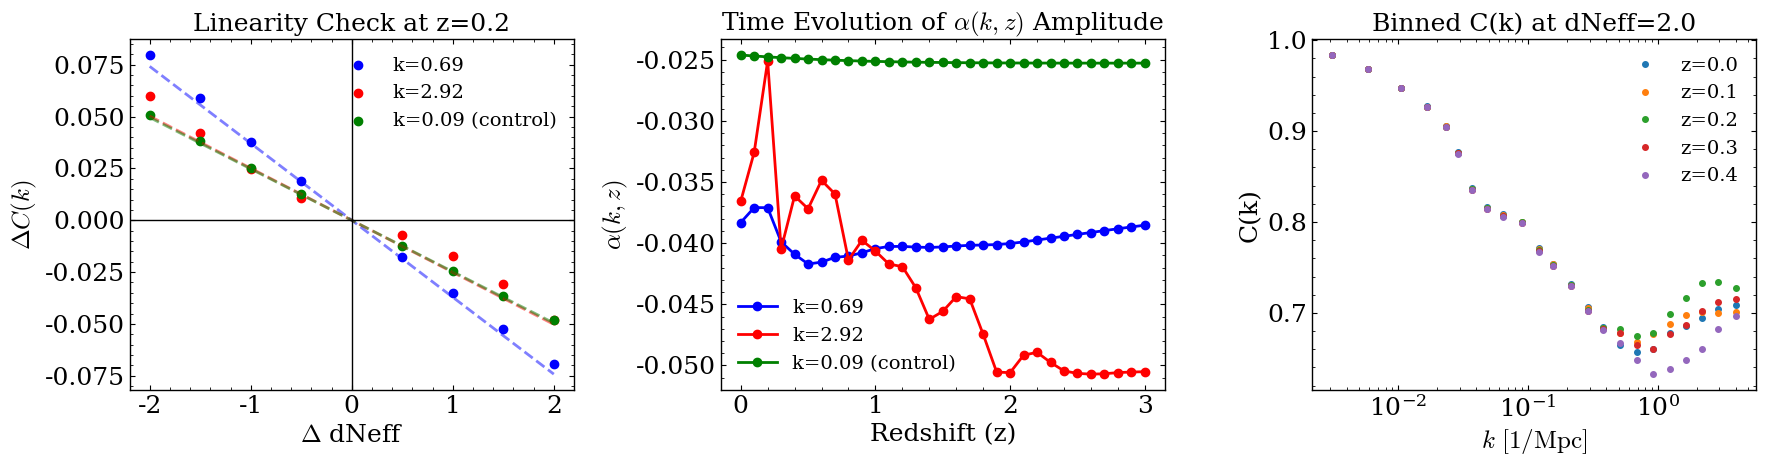

In [4]:
z_to_diagnose = [0.0, 0.1, 0.2, 0.3, 0.4]
plot_param = 'dNeff'  # Change to 'fidm' if you want to plot that response instead

# Find specific k-indices using the BINNED k-array from the cached baseline
k_binned_sample, _ = binned_base[0.0]
k_idx_1 = np.argmin(np.abs(k_binned_sample - 0.8)) # The main dip
k_idx_2 = np.argmin(np.abs(k_binned_sample - 3.0)) # The high-k rise
k_idx_3 = np.argmin(np.abs(k_binned_sample - 0.1)) # A control point in the linear regime

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =================================================================
# DIAGNOSTIC 1: Is the response actually linear?
# =================================================================
ax1 = axes[0]
test_z = 0.2  

x_vals = []
y_vals_dip1 = []
y_vals_dip2 = []
y_vals_control = []

# INSTANT FETCH: Grab the binned baseline
_, Ck_base_binned = binned_base[test_z]

for d_val in sorted(binned_var[plot_param].keys()):
    if test_z in binned_var[plot_param][d_val]:
        # INSTANT FETCH: Grab the binned variation
        _, Ck_var_binned = binned_var[plot_param][d_val][test_z]
        
        x_vals.append(d_val)
        y_vals_dip1.append(Ck_var_binned[k_idx_1] - Ck_base_binned[k_idx_1])
        y_vals_dip2.append(Ck_var_binned[k_idx_2] - Ck_base_binned[k_idx_2])
        y_vals_control.append(Ck_var_binned[k_idx_3] - Ck_base_binned[k_idx_3])

ax1.scatter(x_vals, y_vals_dip1, color='blue', label=f'k={k_binned_sample[k_idx_1]:.2f}')
ax1.scatter(x_vals, y_vals_dip2, color='red', label=f'k={k_binned_sample[k_idx_2]:.2f}')
ax1.scatter(x_vals, y_vals_control, color='green', label=f'k={k_binned_sample[k_idx_3]:.2f} (control)')

# Plot the calculated regression lines
slope1 = response_functions[plot_param][test_z][1][k_idx_1]
slope2 = response_functions[plot_param][test_z][1][k_idx_2]
slope3 = response_functions[plot_param][test_z][1][k_idx_3]

x_line = np.linspace(min(x_vals), max(x_vals), 10)
ax1.plot(x_line, slope1 * x_line, 'b--', alpha=0.5)
ax1.plot(x_line, slope2 * x_line, 'r--', alpha=0.5)
ax1.plot(x_line, slope3 * x_line, 'g--', alpha=0.5)

ax1.set_title(f'Linearity Check at z={test_z}')
ax1.set_xlabel(rf'$\Delta$ {plot_param}')
ax1.set_ylabel(r'$\Delta C(k)$')
ax1.axhline(0, color='k', lw=1)
ax1.axvline(0, color='k', lw=1)
ax1.legend()

# =================================================================
# DIAGNOSTIC 2: The Continuous Redshift Turnaround
# =================================================================
ax2 = axes[1]
all_z = sorted(list(response_functions[plot_param].keys()))
alpha_at_dip1 = [response_functions[plot_param][z][1][k_idx_1] for z in all_z]
alpha_at_dip2 = [response_functions[plot_param][z][1][k_idx_2] for z in all_z]
alpha_at_control = [response_functions[plot_param][z][1][k_idx_3] for z in all_z]

ax2.plot(all_z, alpha_at_dip1, 'b-o', label=f'k={k_binned_sample[k_idx_1]:.2f}')
ax2.plot(all_z, alpha_at_dip2, 'r-o', label=f'k={k_binned_sample[k_idx_2]:.2f}')
ax2.plot(all_z, alpha_at_control, 'g-o', label=f'k={k_binned_sample[k_idx_3]:.2f} (control)')

ax2.set_title(r'Time Evolution of $\alpha(k, z)$ Amplitude')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel(r'$\alpha(k, z)$')
ax2.legend()

# =================================================================
# DIAGNOSTIC 3: Raw Unsubtracted Binned Spectra
# =================================================================
ax3 = axes[2]
test_delta = max(binned_var[plot_param].keys())

for z in z_to_diagnose:
    if z in binned_var[plot_param][test_delta]:
        # INSTANT FETCH: Grab the binned variation for plotting
        k_var_binned, Ck_var_binned = binned_var[plot_param][test_delta][z]
        ax3.plot(k_var_binned, Ck_var_binned, label=f'z={z}', ls='None', marker='o', markersize=4)

ax3.set_xscale('log')
ax3.set_title(f'Binned C(k) at {plot_param}={test_delta}')
ax3.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax3.set_ylabel('C(k)')
ax3.legend()

plt.tight_layout()
plt.show()

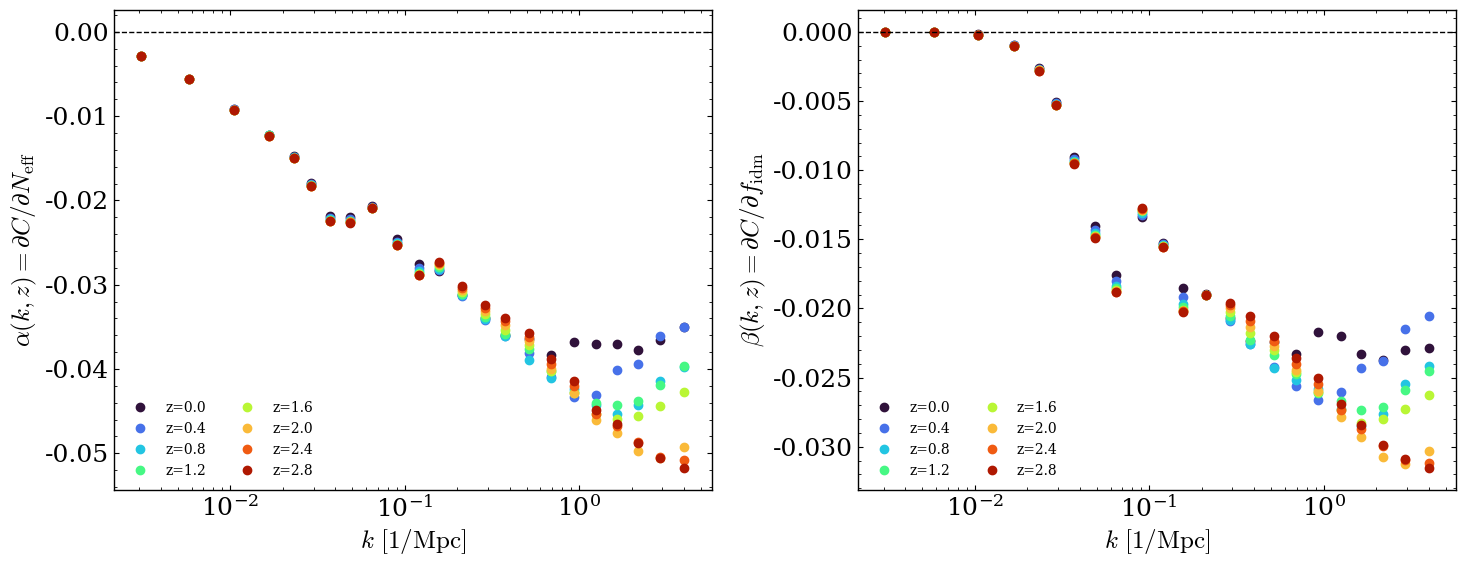

In [5]:
# =================================================================
# 3. PLOT THE RESPONSE FUNCTIONS
# =================================================================
z_to_plot = [0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8] # Choose a few representative redshifts to plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cmap = plt.get_cmap('turbo') 
z_min, z_max = 0.0, 3.0
norm = mpl.colors.Normalize(vmin=z_min, vmax=z_max)

# Plot alpha(k) for dNeff
if 'dNeff' in response_functions and response_functions['dNeff']:
    for z in z_to_plot:
        color = cmap(norm(z))
        if z in response_functions['dNeff']:
            # ---> NEW: Unpack the third 'sigma' item using '_' <---
            k, alpha, _ = response_functions['dNeff'][z]
            ax1.plot(k, alpha, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax1.set_xscale('log')
    ax1.axhline(0, color='black', lw=1, ls='--')
    ax1.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax1.set_ylabel(r'$\alpha(k, z) = \partial C / \partial N_{\mathrm{eff}}$')
    ax1.legend(loc='lower left', ncols=2, fontsize=10)


# Plot beta(k) for fidm
if 'fidm' in response_functions and response_functions['fidm']:
    for z in z_to_plot:
        if z in response_functions['fidm']:
            # ---> NEW: Unpack the third 'sigma' item using '_' <---
            k, beta, _ = response_functions['fidm'][z]
            color = cmap(norm(z))
            ax2.plot(k, beta, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax2.set_xscale('log')
    ax2.axhline(0, color='black', lw=1, ls='--')
    ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax2.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{idm}}$')
    ax2.legend(loc='lower left', ncols=2, fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# =================================================================
# 1. DERIVATIVE MODEL DEFINITION
# =================================================================
def response_model(k, z, A0, gamma_A, B0, gamma_B, kt0, gamma_kt, alpha, beta):
    """
    Fits the derivative response function (alpha or beta).
    Starts at 0, dips to a negative minimum, and rises to a positive asymptote.
    """
    u = 1.0 + z
    
    # --- Time-Evolving Parameters ---
    A_z  = A0  * u**gamma_A   # Amplitude of the negative dip
    B_z  = B0  * u**gamma_B   # Positive High-k asymptote
    kt_z = kt0 * u**gamma_kt  # Transition scale (where it crosses 0)
    
    # --- Functional Components ---
    W = (k**beta) / (kt_z**beta + k**beta)
    
    # Notice the negative sign and POSITIVE alpha exponent!
    f_low = -A_z * k**alpha  
    f_high = B_z
    
    return f_low * (1 - W) + f_high * W

# =================================================================
# 2. GUESSES AND BOUNDS
# =================================================================
p0_dNeff = [
    0.0705,   0.2467,  # A0 (Dip depth scaler), gamma_A 
    -0.0303,  -4.7642,  # B0 (Positive asymptote ~ 0.02), gamma_B
    0.2174,   5.9186,  # kt0 (Zero-crossing scale), gamma_kt
    0.4347,     0.9912   # alpha (Starts flat as k^2 at low k), beta (Must be > alpha to suppress f_low at high k)
]

labels_dNeff = ['A0', 'gamma_A', 'B0', 'gamma_B', 'kt0', 'gamma_kt', 'alpha', 'beta']

# =================================================================
# 3. DATA PREP & FITTING
# =================================================================
z_split = 0.3

# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['dNeff'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)

# Split into Low-z and High-z regimes
mask_low = z_all <= z_split
mask_high = z_all > z_split

print(f"--- Fitting dNeff Response (Low-z) ---")
try:
    popt_resp_low_dNeff, pcov_resp_low_dNeff = curve_fit(
        lambda coords, *p: response_model(coords[0], coords[1], *p),
        (k_all[mask_low], z_all[mask_low]), resp_all[mask_low],
        p0=p0_dNeff, maxfev=150000
    )
    for l, v in zip(labels_dNeff, popt_resp_low_dNeff): 
        print(f"  {l:>6}: {v:.4f}")
except RuntimeError as e:
    print("Fit failed:", e)

print(f"\n--- Fitting dNeff Response (High-z) ---")
try:
    popt_resp_high_dNeff, pcov_resp_high_dNeff = curve_fit(
        lambda coords, *p: response_model(coords[0], coords[1], *p),
        (k_all[mask_high], z_all[mask_high]), resp_all[mask_high],
        p0=p0_dNeff, maxfev=150000
    )
    for l, v in zip(labels_dNeff, popt_resp_high_dNeff): 
        print(f"  {l:>6}: {v:.3f}")
except RuntimeError as e:
    print("Fit failed:", e)

--- Fitting dNeff Response (Low-z) ---
      A0: 0.0705
  gamma_A: 0.2467
      B0: -0.0303
  gamma_B: -4.7636
     kt0: 0.2174
  gamma_kt: 5.9190
   alpha: 0.4346
    beta: 0.9912

--- Fitting dNeff Response (High-z) ---
      A0: 0.108
  gamma_A: -0.226
      B0: -12.390
  gamma_B: -28.323
     kt0: 0.349
  gamma_kt: 1.059
   alpha: 0.446
    beta: 0.654


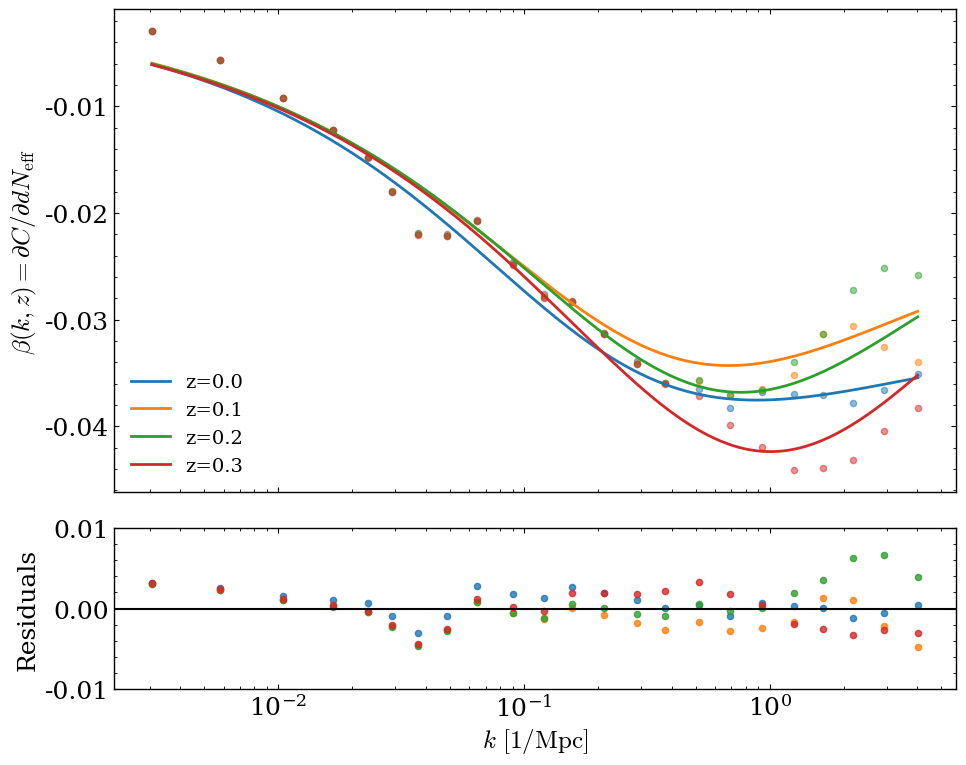

In [7]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================

z_to_plot = [0.0, 0.1, 0.2, 0.3]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['dNeff']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['dNeff'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        if z <= z_split:
            resp_fit = response_model(k_data, z, *popt_resp_low_dNeff)
        else:
            resp_fit = response_model(k_data, z, *popt_resp_high_dNeff)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        if z <= z_split:
            resp_cont = response_model(k_cont, z, *popt_resp_low_dNeff)
        else:
            resp_cont = response_model(k_cont, z, *popt_resp_high_dNeff)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial dN_{\mathrm{eff}}$')


# Clean up legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

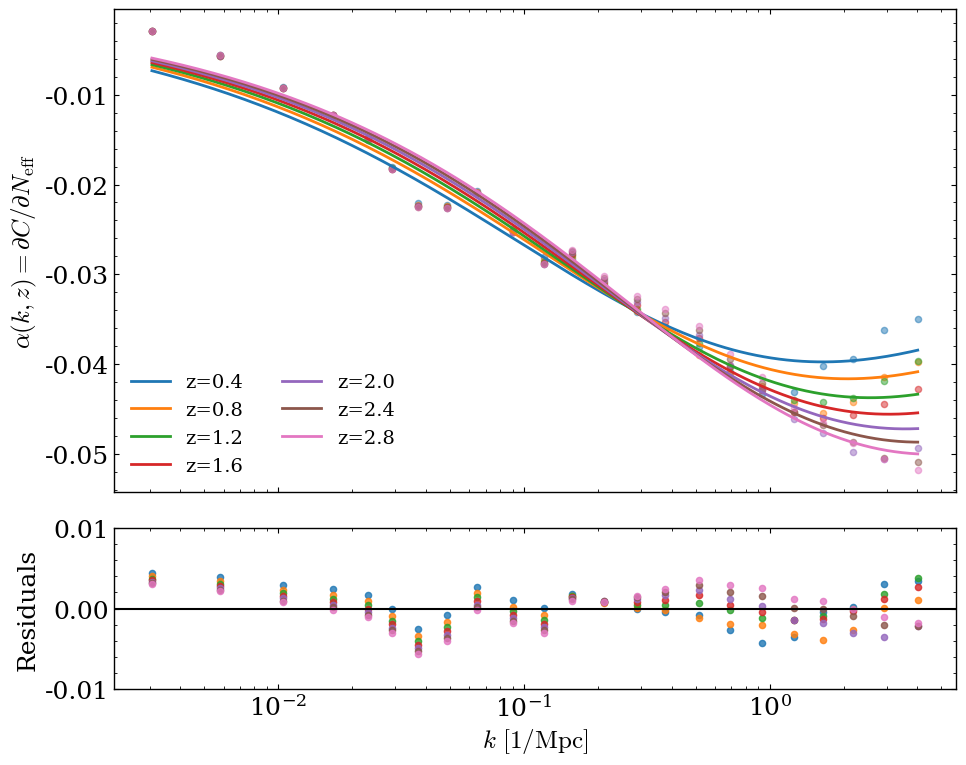

In [8]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['dNeff']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['dNeff'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        if z <= z_split:
            resp_fit = response_model(k_data, z, *popt_resp_low_dNeff)
        else:
            resp_fit = response_model(k_data, z, *popt_resp_high_dNeff)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        if z <= z_split:
            resp_cont = response_model(k_cont, z, *popt_resp_low_dNeff)
        else:
            resp_cont = response_model(k_cont, z, *popt_resp_high_dNeff)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20)
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        # Note: We use (Data - Fit) because dividing by values near 0.0 will cause math errors
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
        # Plot +- 10% residual lines for reference
        # ax2.axhline(10, color='gray', lw=1, ls='--')
        # ax2.axhline(-10, color='gray', lw=1, ls='--')

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\alpha(k, z) = \partial C / \partial N_{\mathrm{eff}}$')

# Clean up legend to avoid duplicates
ax1.legend(ncols = 2, loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

In [22]:
# =================================================================
# 2. GUESSES AND BOUNDS FOR f_idm
# =================================================================
p0_fidm_low = [
    -1,  0.50, # A0 (Dip depth scaler), gamma_A 
   -0.3,  -1.0, # B0 (fidm has a NEGATIVE high-k asymptote ~ -0.03!), gamma_B
    0.35,  1.0, # kt0 (fidm dips much earlier than dNeff, around k=0.15), gamma_kt
    2.00,         # alpha 
    2.50          # beta 
]

bounds_fidm_low = (
    # A0,   gamma_A, B0, gamma_B,    kt0,  gamma_kt, alpha, beta
    [-8.38,   -5.0,   -10,    -100,    -0.2, -5.0,     -0.50,  -1.00], # Lower (B0 is allowed to be negative!)
    [0,     5.0,   -0.01,  100,    100,   5.0,     5.00, 15.00]  # Upper
)

p0_fidm_high = [
    0.20,  1.00, # A0 (Dip depth is ~0.06, so A0~0.2 is perfect), gamma_A 
   -0.02,  -1.00, # B0 (Negative asymptote), gamma_B 
    0.05,   0.00, # kt0 (Dip minimum is around 0.05), gamma_kt
    2.00,         # alpha 
    2.50          # beta 
]

bounds_fidm_high = (
    # A0,   gamma_A, B0,     gamma_B, kt0,   gamma_kt, alpha, beta
    [-1000, 0.1,    -10.0, -15.0,     0.001, -3.0,     0.05,  0.05], # Lower 
    [200,  15.0,    10.001,    100,    10.000,  3.0,     5.00, 10.00]  # Upper
)

labels_fidm = ['A0', 'gamma_A', 'B0', 'gamma_B', 'kt0', 'gamma_kt', 'alpha', 'beta']

# =================================================================
# 3. EXECUTION (WITH BOUNDS RE-ADDED)
# =================================================================
# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['fidm'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)
sigma_all = np.concatenate(sigma_all)

# Split into Low-z and High-z regimes
mask_low = z_all <= z_split
mask_high = z_all > z_split

print(f"--- Fitting fidm Response (Low-z) ---")
try:
    popt_resp_low_fidm, pcov_resp_low_fidm = curve_fit(
        lambda coords, *p: response_model(coords[0], coords[1], *p),
        (k_all[mask_low], z_all[mask_low]), resp_all[mask_low],
        p0=p0_fidm_low, 
        bounds=bounds_fidm_low, 
        sigma=sigma_all[mask_low], # (Optional) Added here too just in case!
        maxfev=150000
    )
    for l, v in zip(labels_fidm, popt_resp_low_fidm): 
        print(f"  {l:>6}: {v:.4f}")
except RuntimeError as e:
    print("Fit failed:", e)

print(f"\n--- Fitting fidm Response (High-z) ---")
try:
    popt_resp_high_fidm, pcov_resp_high_fidm = curve_fit(
        lambda coords, *p: response_model(coords[0], coords[1], *p),
        (k_all[mask_high], z_all[mask_high]), resp_all[mask_high],
        p0=p0_fidm_high, 
        bounds=bounds_fidm_high, 
        sigma=sigma_all[mask_high], # <--- Now this will work perfectly!
        maxfev=150000
    )
    for l, v in zip(labels_fidm, popt_resp_high_fidm): 
        print(f"  {l:>6}: {v:.3f}")
except RuntimeError as e:
    print("Fit failed:", e)

--- Fitting fidm Response (Low-z) ---
      A0: -8.3800
  gamma_A: 3.7346
      B0: -0.0211
  gamma_B: 0.3233
     kt0: 0.0298
  gamma_kt: -0.8030
   alpha: 1.9431
    beta: 2.7706

--- Fitting fidm Response (High-z) ---
      A0: -0.004
  gamma_A: 3.484
      B0: -0.019
  gamma_B: 0.477
     kt0: 0.052
  gamma_kt: 0.022
   alpha: 1.067
    beta: 1.400


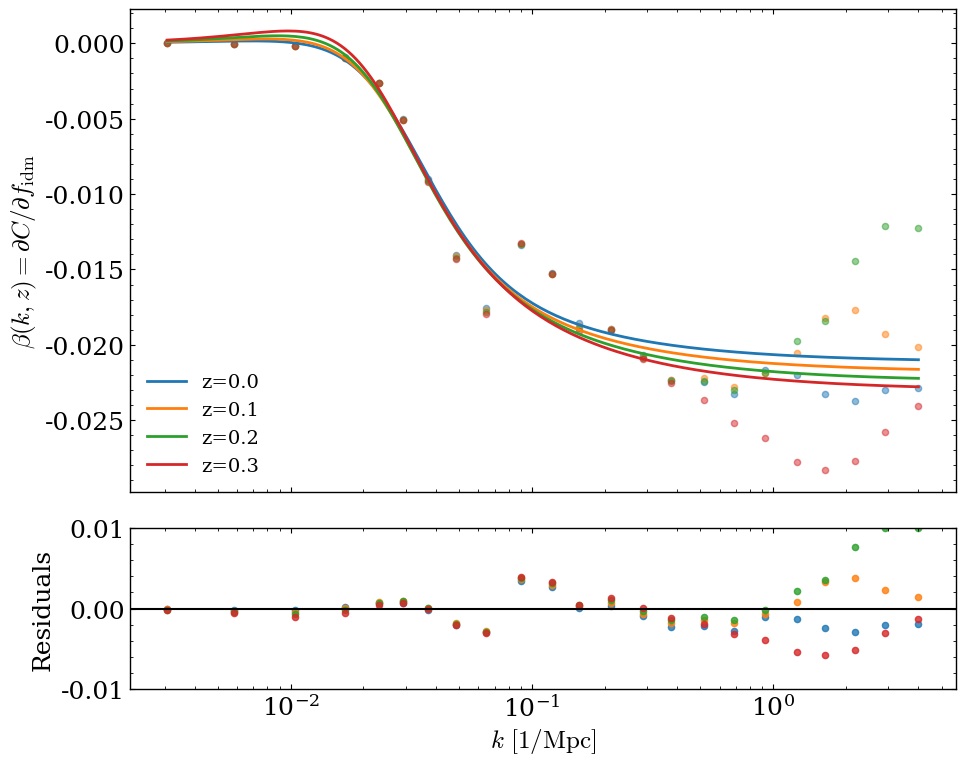

In [18]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.0, 0.1, 0.2, 0.3]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['fidm']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['fidm'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        if z <= z_split:
            resp_fit = response_model(k_data, z, *popt_resp_low_fidm)
        else:
            resp_fit = response_model(k_data, z, *popt_resp_high_fidm)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        if z <= z_split:
            resp_cont = response_model(k_cont, z, *popt_resp_low_fidm)
        else:
            resp_cont = response_model(k_cont, z, *popt_resp_high_fidm)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{idm}}$')


# Clean up legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

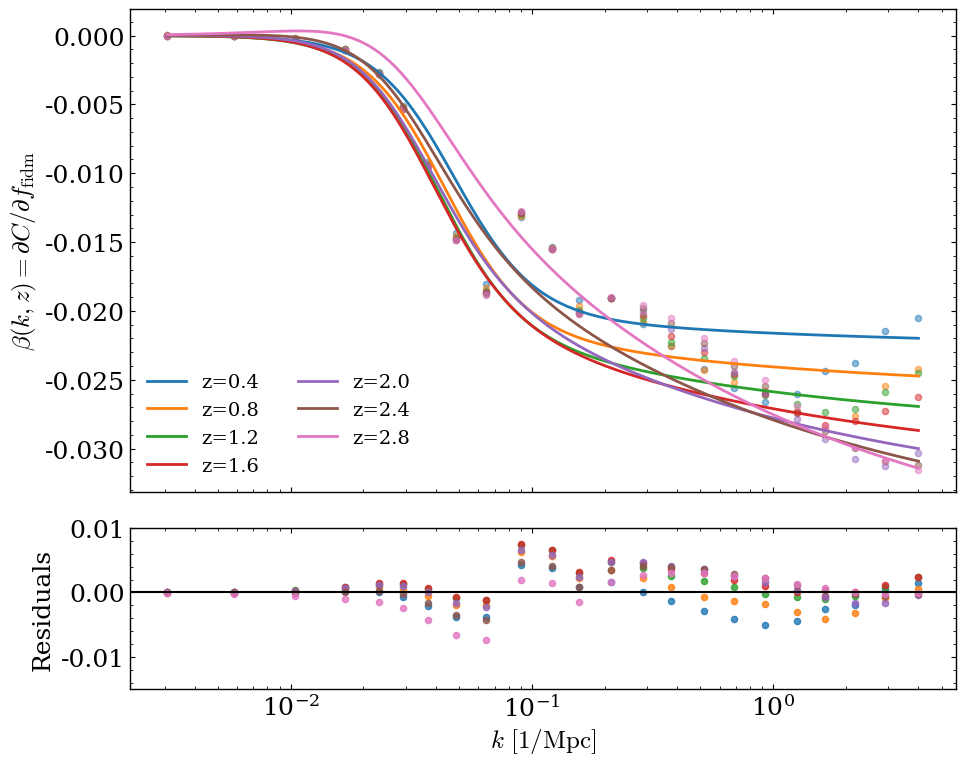

In [19]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['fidm']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['fidm'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        if z <= z_split:
            resp_fit = response_model(k_data, z, *popt_resp_low_fidm)
        else:
            resp_fit = response_model(k_data, z, *popt_resp_high_fidm)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        if z <= z_split:
            resp_cont = response_model(k_cont, z, *popt_resp_low_fidm)
        else:
            resp_cont = response_model(k_cont, z, *popt_resp_high_fidm)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20)
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        # Note: We use (Data - Fit) because dividing by values near 0.0 will cause math errors
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
        # Plot +- 10% residual lines for reference
        # ax2.axhline(10, color='gray', lw=1, ls='--')
        # ax2.axhline(-10, color='gray', lw=1, ls='--')

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{fidm}}$')

# Clean up legend to avoid duplicates
ax1.legend(ncols = 2, loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.015, 0.01)

plt.tight_layout()
plt.show()

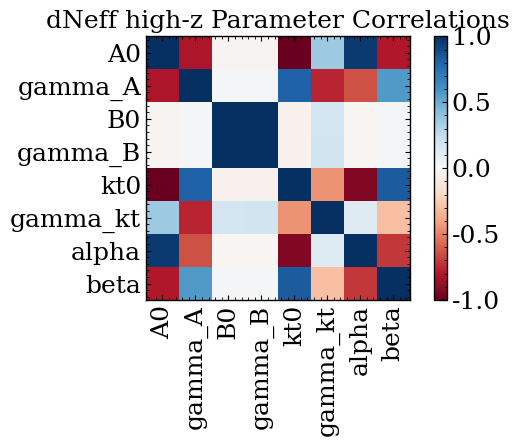

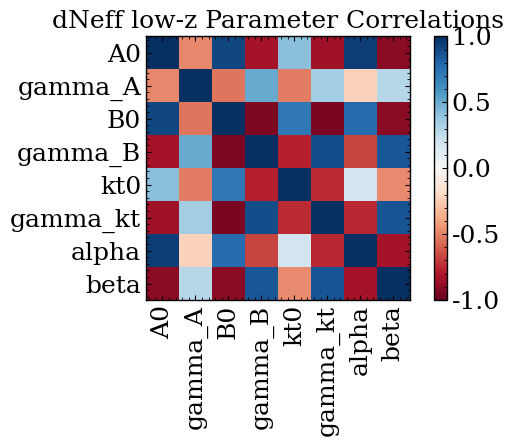

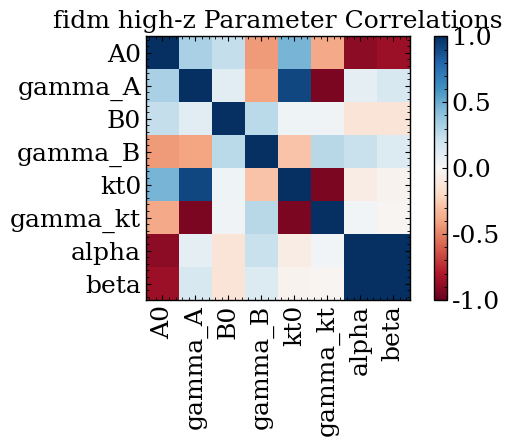

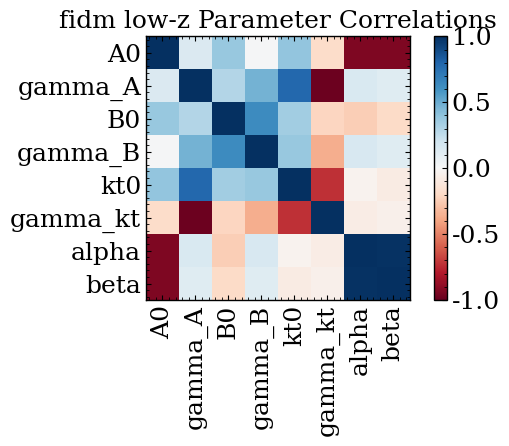

In [20]:
# dNeff high-z correlation matrix
perr_high_dNeff = np.sqrt(np.diag(pcov_resp_high_dNeff))
corr_matrix_high_dNeff = pcov_resp_high_dNeff / np.outer(perr_high_dNeff, perr_high_dNeff)
plt.imshow(corr_matrix_high_dNeff, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels_dNeff)), labels_dNeff, rotation=90)
plt.yticks(range(len(labels_dNeff)), labels_dNeff)
plt.title("dNeff high-z Parameter Correlations")
plt.tight_layout()
plt.show()

# dNeff low-z correlation matrix
perr_low_dNeff = np.sqrt(np.diag(pcov_resp_low_dNeff))
corr_matrix_low_dNeff = pcov_resp_low_dNeff / np.outer(perr_low_dNeff, perr_low_dNeff)
plt.figure()
plt.imshow(corr_matrix_low_dNeff, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels_dNeff)), labels_dNeff, rotation=90)
plt.yticks(range(len(labels_dNeff)), labels_dNeff)
plt.title("dNeff low-z Parameter Correlations")
plt.tight_layout()
plt.show()

# fidm high-z correlation matrix
perr_high_fidm = np.sqrt(np.diag(pcov_resp_high_fidm))
corr_matrix_high_fidm = pcov_resp_high_fidm / np.outer(perr_high_fidm, perr_high_fidm)
plt.imshow(corr_matrix_high_fidm, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels_fidm)), labels_fidm, rotation=90)
plt.yticks(range(len(labels_fidm)), labels_fidm)
plt.title("fidm high-z Parameter Correlations")
plt.tight_layout()
plt.show()

# fidm low-z correlation matrix
perr_low_fidm = np.sqrt(np.diag(pcov_resp_low_fidm))
corr_matrix_low_fidm = pcov_resp_low_fidm / np.outer(perr_low_fidm, perr_low_fidm)
plt.figure()
plt.imshow(corr_matrix_low_fidm, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels_fidm)), labels_fidm, rotation=90)
plt.yticks(range(len(labels_fidm)), labels_fidm)
plt.title("fidm low-z Parameter Correlations")
plt.tight_layout()
plt.show()

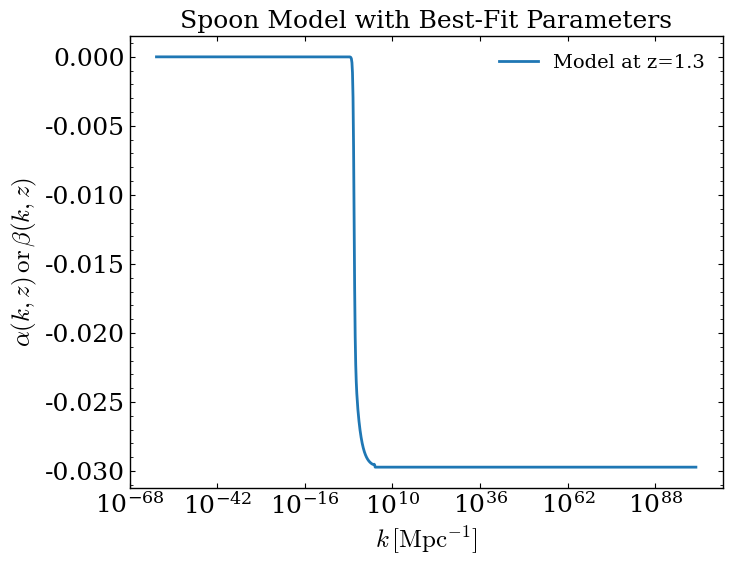

In [21]:
def test_response(target_param, k, z):
    if z < 0.4 and target_param == 'dNeff':
        response_test = response_model(k_test, z, *popt_resp_low_dNeff)
    elif z >= 0.4 and target_param == 'dNeff':
        response_test = response_model(k_test, z, *popt_resp_high_dNeff)
    elif z < 0.4 and target_param == 'fidm':
        response_test = response_model(k_test, z, *popt_resp_low_fidm)
    elif z >= 0.4 and target_param == 'fidm':
        response_test = response_model(k_test, z, *popt_resp_high_fidm)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.semilogx(k_test, response_test, label=f'Model at z={z}')
    ax.set_xscale('log')
    ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$\alpha(k,z)\,\mathrm{or}\,\beta(k, z)$')
    ax.set_title('Spoon Model with Best-Fit Parameters')
    ax.legend()
    plt.tight_layout()
    plt.show()

k_test = np.logspace(-60, 100, 1000)

test_response('fidm', k_test, 1.3)

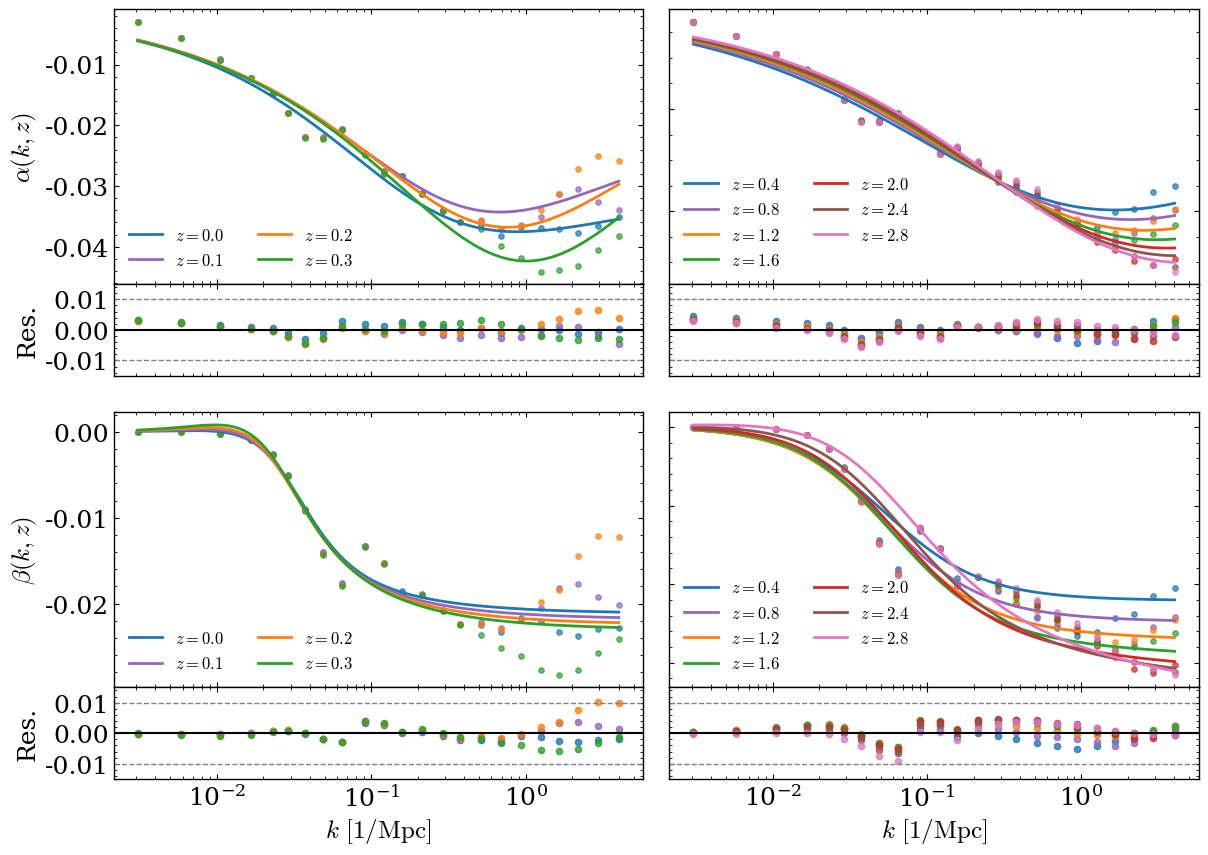

In [14]:
# --- Alpha (dNeff) Params ---
zlow_alpha_params_dict = {
      'A0': popt_resp_low_dNeff[0],
      'gamma_A': popt_resp_low_dNeff[1],
      'B0': popt_resp_low_dNeff[2],
      'gamma_B': popt_resp_low_dNeff[3],
      'kt0': popt_resp_low_dNeff[4],
      'gamma_kt': popt_resp_low_dNeff[5],
      'alpha': popt_resp_low_dNeff[6],
      'beta': popt_resp_low_dNeff[7]
}

zhigh_alpha_params_dict = {
      'A0': popt_resp_high_dNeff[0],
      'gamma_A': popt_resp_high_dNeff[1],
      'B0': popt_resp_high_dNeff[2],
      'gamma_B': popt_resp_high_dNeff[3],
      'kt0': popt_resp_high_dNeff[4],
      'gamma_kt': popt_resp_high_dNeff[5],
      'alpha': popt_resp_high_dNeff[6],
      'beta': popt_resp_high_dNeff[7]
}

# --- Beta (fidm) Params ---
zlow_beta_params_dict = {
      'A0': popt_resp_low_fidm[0],
      'gamma_A': popt_resp_low_fidm[1],
      'B0': popt_resp_low_fidm[2],
      'gamma_B': popt_resp_low_fidm[3],
      'kt0': popt_resp_low_fidm[4],
      'gamma_kt': popt_resp_low_fidm[5],
      'alpha': popt_resp_low_fidm[6],
      'beta': popt_resp_low_fidm[7]
}

zhigh_beta_params_dict = {
      'A0': popt_resp_high_fidm[0],
      'gamma_A': popt_resp_high_fidm[1],
      'B0': popt_resp_high_fidm[2],
      'gamma_B': popt_resp_high_fidm[3],
      'kt0': popt_resp_high_fidm[4],
      'gamma_kt': popt_resp_high_fidm[5],
      'alpha': popt_resp_high_fidm[6],
      'beta': popt_resp_high_fidm[7]
}

# 1. Define the parameters for the grid
z_low_plot = [0.0, 0.1, 0.2, 0.3]   # Replace with your actual low-z values to plot
z_high_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]  # Replace with your actual high-z values to plot

# Define the 4 panels we want to create
panels = [
    {
        'param': 'dNeff', 'regime': 'low', 'z_list': z_low_plot, 
        'title': r'$\alpha(k, z)$ (Response to $\Delta N_{\rm eff}$) - Low $z$',
        'ylabel': r'$\alpha(k, z)$',
        'fit_func': response_model, # Assuming this is your low-z function name
        'fit_params': zlow_alpha_params_dict
    },
    {
        'param': 'dNeff', 'regime': 'high', 'z_list': z_high_plot, 
        'title': r'$\alpha(k, z)$ (Response to $\Delta N_{\rm eff}$) - High $z$',
        'ylabel': r'$\alpha(k, z)$',
        'fit_func': response_model,   # Your high-z function
        'fit_params': zhigh_alpha_params_dict
    },
    {
        'param': 'fidm', 'regime': 'low', 'z_list': z_low_plot, 
        'title': r'$\beta(k, z)$ (Response to $f_{\rm idm}$) - Low $z$',
        'ylabel': r'$\beta(k, z)$',
        'fit_func': response_model,
        'fit_params': zlow_beta_params_dict
    },
    {
        'param': 'fidm', 'regime': 'high', 'z_list': z_high_plot, 
        'title': r'$\beta(k, z)$ (Response to $f_{\rm idm}$) - High $z$',
        'ylabel': r'$\beta(k, z)$',
        'fit_func': response_model,
        'fit_params': zhigh_beta_params_dict
    }
]

# Set up outer figure (matching proportion and reducing hspace for shared x-axis)
fig = plt.figure(figsize=(14, 10))
outer_gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.05, hspace=0.10)

# Use a nice color map for the z-values
colors = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown', 'tab:pink', 'tab:gray']

# Loop through the 4 panels
for i, panel in enumerate(panels):
    # Determine position in the 2x2 grid
    row, col = divmod(i, 2)
    
    # Create inner GridSpec for main plot + residuals (Height ratio 3:1)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row, col], 
                                                height_ratios=[3, 1], hspace=0.0)
    
    ax1 = fig.add_subplot(inner_gs[0])
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    target_param = panel['param']
    func = panel['fit_func']
    popt = panel['fit_params']
    
    for z, color in zip(panel['z_list'], colors):
        if z in response_functions[target_param]:
            # 1. Get the Exact Data
            k_data, resp_data, sigma_data = response_functions[target_param][z]
            
            # 2. Calculate Analytical Fit 
            resp_fit = func(k_data, z, **popt)
            
            # 3. Plot Data & Continuous Line
            k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
            resp_cont = func(k_cont, z, **popt)
            
            # Updated to match plot 1 marker style and label math formatting
            ax1.scatter(k_data, resp_data, color=color, alpha=0.7, s=15)
            ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'$z={z}$')
            
            # 4. Plot Absolute Residuals 
            with np.errstate(divide='ignore', invalid='ignore'):
                resid = (resp_data - resp_fit)
                
            ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

    # --- Formatting Top Panel (ax1) ---
    ax1.set_xscale('log')
    
    if col == 0:
        ax1.set_ylabel(panel['ylabel'])
    else:
        plt.setp(ax1.get_yticklabels(), visible=False)
        
    plt.setp(ax1.get_xticklabels(), visible=False) 
    
    # Clean legend matching plot 1
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='lower left', ncol=2, fontsize=12)

    # --- Formatting Bottom Panel (ax2) ---
    ax2.axhline(0, color='black', lw=1.5, ls='-')
    ax2.axhline(0.01, color='gray', lw=1, ls='--')  # Changed from 10 to 0.01 to fit ylim
    ax2.axhline(-0.01, color='gray', lw=1, ls='--') # Changed from -10 to -0.01 to fit ylim
    
    # Left-axis label logic
    if col == 0:
        ax2.set_ylabel('Res.')
    else:
        plt.setp(ax2.get_yticklabels(), visible=False)
        
    ax2.set_ylim(-0.015, 0.015) 
    
    # Shared X-axis logic (Only bottom row gets x-labels and ticks)
    if row == 1:
        ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    else:
        plt.setp(ax2.get_xticklabels(), visible=False)

plt.savefig('alpha_beta_fits.pdf', bbox_inches='tight')
plt.show()